# 📊 Analyse Exploratoire des Données RSSI

Ce notebook présente une analyse exploratoire complète des données RSSI pour le projet de géolocalisation indoor.

## Objectifs
- Comprendre la distribution des signaux RSSI
- Identifier les patterns et corrélations
- Détecter les valeurs aberrantes
- Visualiser la qualité des données

In [1]:
# Imports nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Ajouter le chemin vers le module src
import sys
import os
sys.path.append(os.path.join('..', 'src'))

from data_preprocessing import RSSIDataProcessor
from visualization import RSSIVisualizer

## 1. Chargement des Données

In [2]:
# Initialiser le processeur de données
processor = RSSIDataProcessor()
visualizer = RSSIVisualizer()

# Charger les données RSSI
data_path = '../data'
dataframes = processor.load_rssi_data(data_path)

print("📁 Fichiers chargés:")
for key, df in dataframes.items():
    print(f"  - {key}: {df.shape}")

INFO:data_preprocessing:Chargement des données depuis ../data
INFO:data_preprocessing:✓ rssi_0: (74, 51)
INFO:data_preprocessing:✓ rssi_1: (74, 51)
INFO:data_preprocessing:✓ rssi_2: (74, 51)
INFO:data_preprocessing:✓ rssi_3: (74, 51)


📁 Fichiers chargés:
  - rssi_0: (74, 51)
  - rssi_1: (74, 51)
  - rssi_2: (74, 51)
  - rssi_3: (74, 51)


## 2. Statistiques Descriptives

In [3]:
# Créer la matrice de features
X = processor.create_feature_matrix(dataframes)
y = processor.generate_synthetic_targets(len(X))

# Calculer les statistiques
stats = processor.get_data_statistics(X, y)

print("📈 Statistiques générales:")
print(f"  - Nombre d'échantillons: {stats['n_samples']}")
print(f"  - Nombre de features: {stats['n_features']}")
print(f"  - Valeurs manquantes: {stats['missing_values']}")
print(f"  - RSSI min: {stats['rssi_range']['min']:.2f} dBm")
print(f"  - RSSI max: {stats['rssi_range']['max']:.2f} dBm")
print(f"  - RSSI moyen: {stats['rssi_range']['mean']:.2f} dBm")

INFO:data_preprocessing:Création de la matrice de features
INFO:data_preprocessing:Matrice de features créée: (55, 200)
INFO:data_preprocessing:Génération de 55 coordonnées cibles synthétiques


📈 Statistiques générales:
  - Nombre d'échantillons: 55
  - Nombre de features: 200
  - Valeurs manquantes: 0
  - RSSI min: -72.91 dBm
  - RSSI max: -30.96 dBm
  - RSSI moyen: -53.56 dBm


## 3. Distribution des Valeurs RSSI

In [8]:
# Graphique de distribution par capteur
fig = visualizer.plot_rssi_distribution(dataframes)
plt.show()

# Statistiques par capteur
print("\n📊 Statistiques par capteur:")
for key, df in dataframes.items():
    values = df.values.flatten()
    values = values[~np.isnan(values)]
    print(f"\n{key.upper()}:")
    print(f"  - Moyenne: {np.mean(values):.2f} dBm")
    print(f"  - Médiane: {np.median(values):.2f} dBm")
    print(f"  - Écart-type: {np.std(values):.2f} dBm")
    print(f"  - Min/Max: {np.min(values):.2f} / {np.max(values):.2f} dBm")


📊 Statistiques par capteur:

RSSI_0:
  - Moyenne: -55.50 dBm
  - Médiane: -55.94 dBm
  - Écart-type: 7.31 dBm
  - Min/Max: -74.35 / -30.96 dBm

RSSI_1:
  - Moyenne: -53.99 dBm
  - Médiane: -53.93 dBm
  - Écart-type: 9.35 dBm
  - Min/Max: -72.14 / -30.96 dBm

RSSI_2:
  - Moyenne: -50.90 dBm
  - Médiane: -50.78 dBm
  - Écart-type: 6.28 dBm
  - Min/Max: -68.59 / -30.96 dBm

RSSI_3:
  - Moyenne: -54.56 dBm
  - Médiane: -54.99 dBm
  - Écart-type: 7.85 dBm
  - Min/Max: -72.28 / -30.96 dBm


## 4. Analyse des Corrélations

In [10]:
# Matrice de corrélation (échantillon pour performance)
sample_size = min(50, X.shape[1])  # Prendre un échantillon des features
X_sample = X.iloc[:, :sample_size]

# Heatmap de corrélation
fig = visualizer.plot_rssi_heatmap(X_sample, "Matrice de Corrélation (échantillon)")
plt.show()

# Corrélations les plus fortes
corr_matrix = X_sample.corr()
# Extraire les corrélations supérieures à 0.8 (hors diagonale)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    print("\n🔗 Corrélations élevées (>0.8):")
    for corr in high_corr[:10]:  # Top 10
        print(f"  - {corr['Feature1']} ↔ {corr['Feature2']}: {corr['Correlation']:.3f}")
else:
    print("\n✅ Aucune corrélation élevée détectée dans l'échantillon")


🔗 Corrélations élevées (>0.8):
  - 0 ↔ 1: 0.920
  - 0 ↔ 2: 0.844
  - 0 ↔ 35: 0.809
  - 0 ↔ 36: 0.830
  - 0 ↔ 37: 0.835
  - 0 ↔ 38: 0.859
  - 0 ↔ 39: 0.866
  - 0 ↔ 40: 0.856
  - 0 ↔ 41: 0.852
  - 0 ↔ 42: 0.824


## 5. Détection des Valeurs Aberrantes

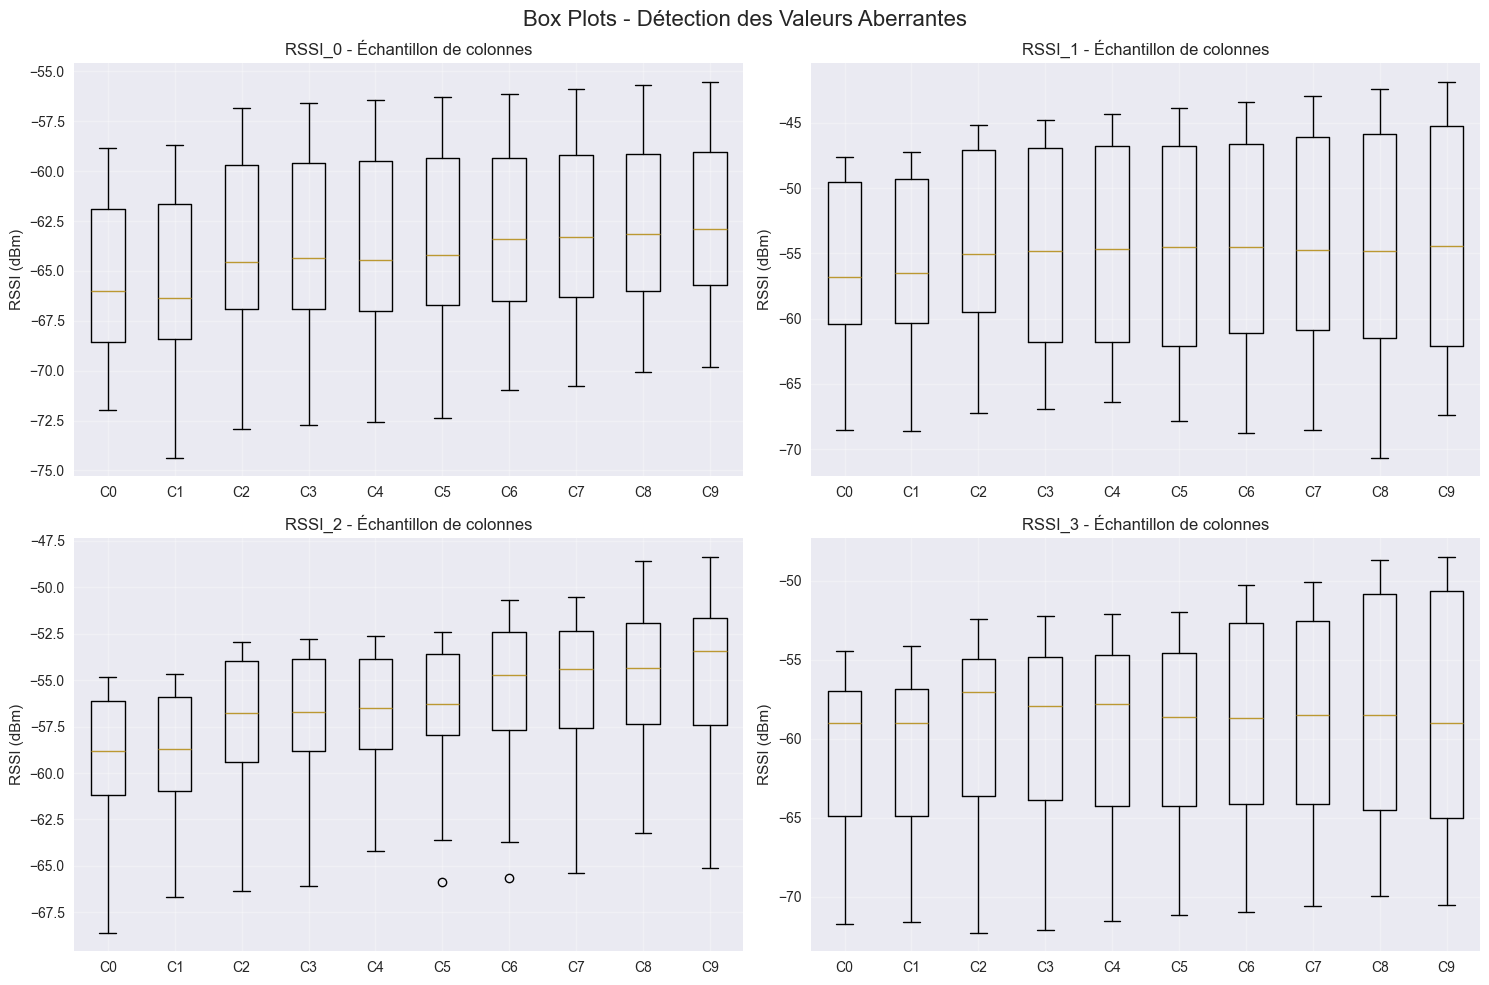


🎯 Analyse des valeurs aberrantes:

RSSI_0:
  - Q1/Q3: -59.85 / -51.44 dBm
  - IQR: 8.40 dBm
  - Seuils: [-72.45, -38.84] dBm
  - Outliers: 98 (2.7%)

RSSI_1:
  - Q1/Q3: -62.66 / -46.17 dBm
  - IQR: 16.49 dBm
  - Seuils: [-87.40, -21.43] dBm
  - Outliers: 0 (0.0%)

RSSI_2:
  - Q1/Q3: -55.80 / -46.68 dBm
  - IQR: 9.12 dBm
  - Seuils: [-69.47, -33.00] dBm
  - Outliers: 12 (0.3%)

RSSI_3:
  - Q1/Q3: -60.60 / -49.07 dBm
  - IQR: 11.53 dBm
  - Seuils: [-77.89, -31.78] dBm
  - Outliers: 3 (0.1%)


In [11]:
# Box plots pour détecter les outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Box Plots - Détection des Valeurs Aberrantes', fontsize=16)

for i, (key, df) in enumerate(dataframes.items()):
    row, col = i // 2, i % 2
    
    # Échantillonner quelques colonnes pour la visualisation
    sample_cols = df.columns[:min(10, len(df.columns))]
    data_to_plot = [df[col].dropna().values for col in sample_cols]
    
    axes[row, col].boxplot(data_to_plot, labels=[f'C{j}' for j in range(len(sample_cols))])
    axes[row, col].set_title(f'{key.upper()} - Échantillon de colonnes')
    axes[row, col].set_ylabel('RSSI (dBm)')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques des outliers
print("\n🎯 Analyse des valeurs aberrantes:")
for key, df in dataframes.items():
    values = df.values.flatten()
    values = values[~np.isnan(values)]
    
    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = values[(values < lower_bound) | (values > upper_bound)]
    outlier_percentage = (len(outliers) / len(values)) * 100
    
    print(f"\n{key.upper()}:")
    print(f"  - Q1/Q3: {Q1:.2f} / {Q3:.2f} dBm")
    print(f"  - IQR: {IQR:.2f} dBm")
    print(f"  - Seuils: [{lower_bound:.2f}, {upper_bound:.2f}] dBm")
    print(f"  - Outliers: {len(outliers)} ({outlier_percentage:.1f}%)")

## 6. Analyse Temporelle (si applicable)

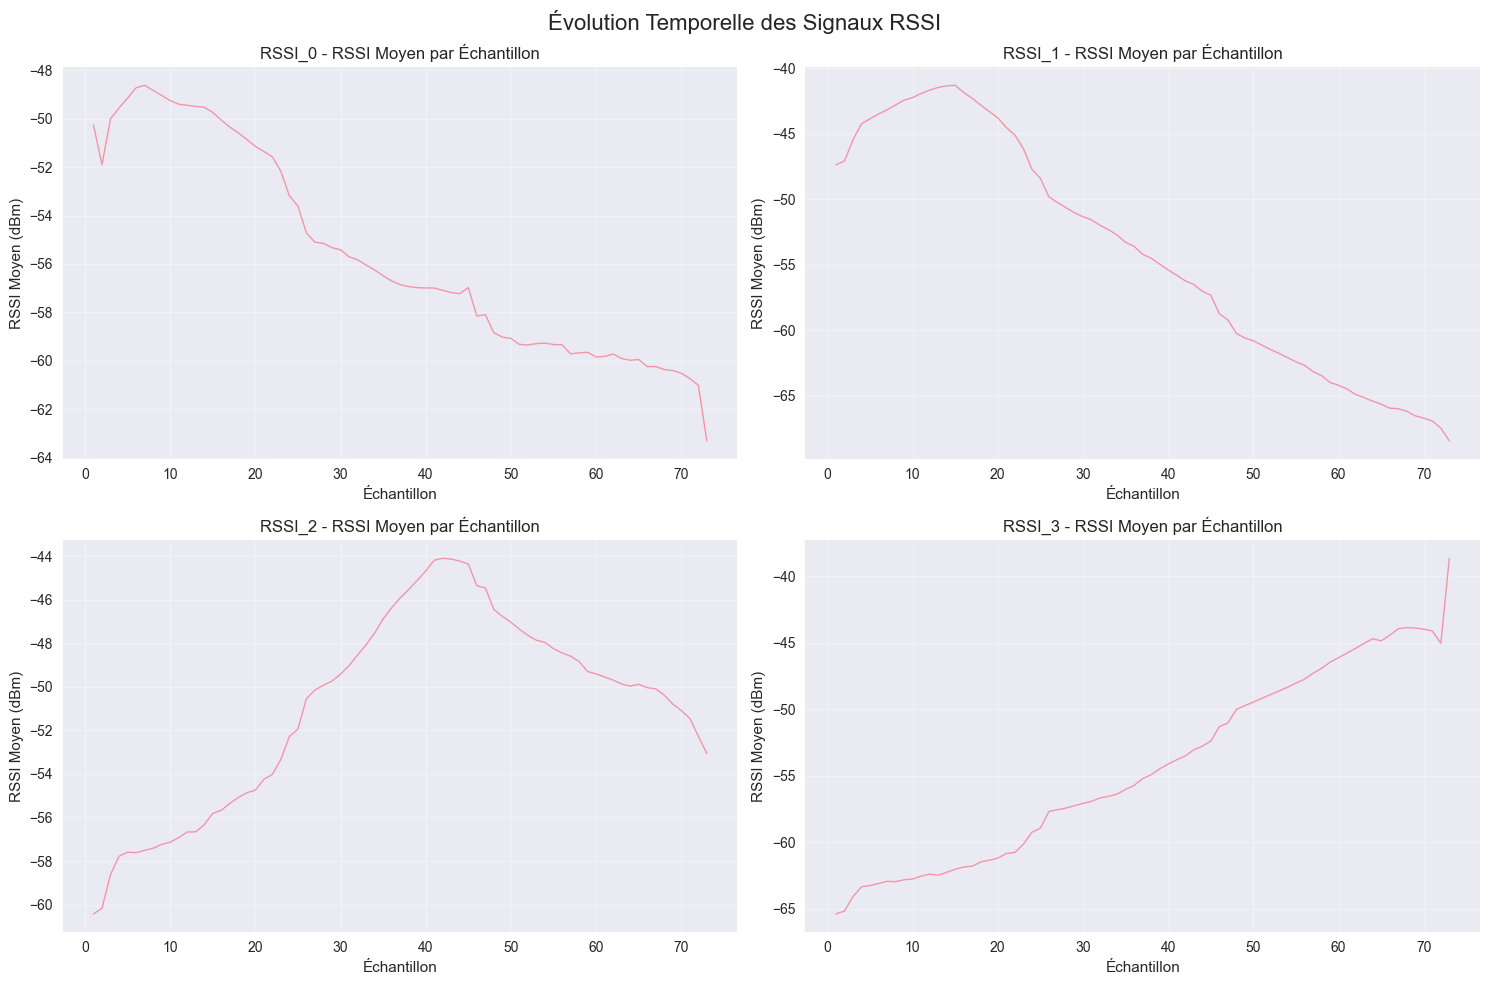

In [12]:
# Évolution des signaux RSSI dans le temps (par ligne = échantillon temporel)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Évolution Temporelle des Signaux RSSI', fontsize=16)

for i, (key, df) in enumerate(dataframes.items()):
    row, col = i // 2, i % 2
    
    # Prendre les premières colonnes et moyenner par ligne
    sample_data = df.iloc[:, :min(50, df.shape[1])]
    mean_rssi = sample_data.mean(axis=1, skipna=True)
    
    axes[row, col].plot(mean_rssi.index, mean_rssi.values, alpha=0.7, linewidth=1)
    axes[row, col].set_title(f'{key.upper()} - RSSI Moyen par Échantillon')
    axes[row, col].set_xlabel('Échantillon')
    axes[row, col].set_ylabel('RSSI Moyen (dBm)')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Analyse des Données Manquantes

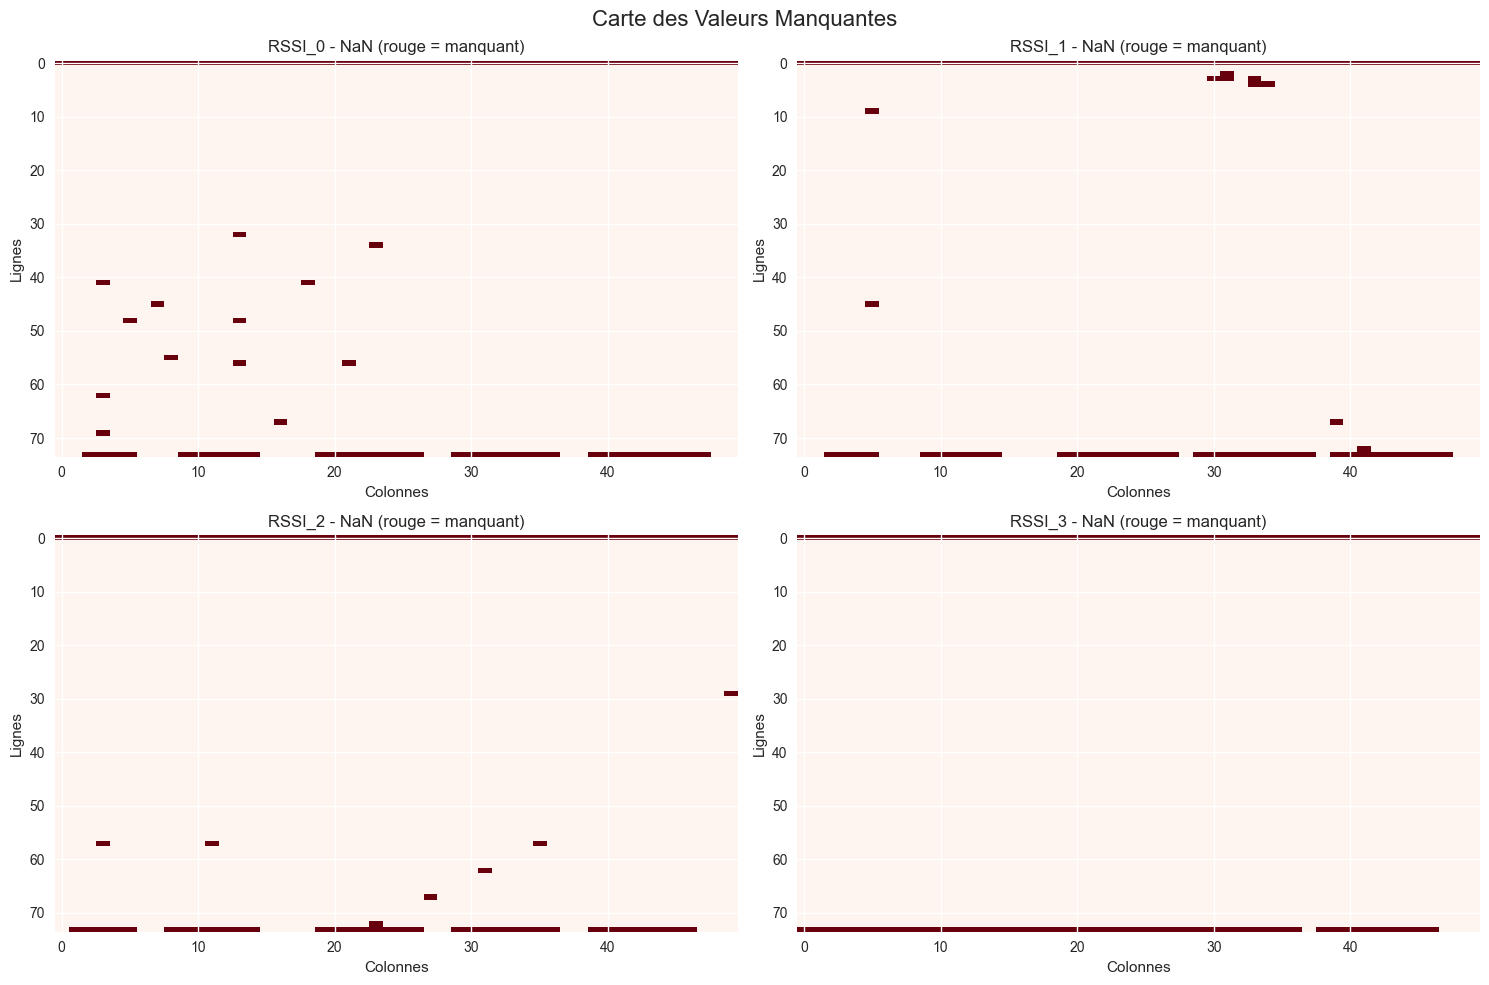


❌ Analyse des valeurs manquantes:

RSSI_0:
  - Total manquant: 172/3774 (4.6%)
  - Colonnes les plus affectées:
    - Colonne 50: 74 (100.0%)
    - Colonne 13: 5 (6.8%)
    - Colonne 3: 5 (6.8%)
    - Colonne 21: 3 (4.1%)
    - Colonne 23: 3 (4.1%)

RSSI_1:
  - Total manquant: 171/3774 (4.5%)
  - Colonnes les plus affectées:
    - Colonne 50: 74 (100.0%)
    - Colonne 31: 4 (5.4%)
    - Colonne 5: 4 (5.4%)
    - Colonne 33: 4 (5.4%)
    - Colonne 34: 3 (4.1%)

RSSI_2:
  - Total manquant: 167/3774 (4.4%)
  - Colonnes les plus affectées:
    - Colonne 50: 74 (100.0%)
    - Colonne 11: 3 (4.1%)
    - Colonne 3: 3 (4.1%)
    - Colonne 31: 3 (4.1%)
    - Colonne 35: 3 (4.1%)

RSSI_3:
  - Total manquant: 170/3774 (4.5%)
  - Colonnes les plus affectées:
    - Colonne 50: 74 (100.0%)
    - Colonne 1: 2 (2.7%)
    - Colonne 0: 2 (2.7%)
    - Colonne 3: 2 (2.7%)
    - Colonne 4: 2 (2.7%)


In [13]:
# Heatmap des valeurs manquantes
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Carte des Valeurs Manquantes', fontsize=16)

for i, (key, df) in enumerate(dataframes.items()):
    row, col = i // 2, i % 2
    
    # Échantillonner pour la visualisation
    sample_df = df.iloc[:min(100, df.shape[0]), :min(50, df.shape[1])]
    
    # Créer une matrice binaire des NaN
    nan_matrix = sample_df.isnull().astype(int)
    
    im = axes[row, col].imshow(nan_matrix, cmap='Reds', aspect='auto')
    axes[row, col].set_title(f'{key.upper()} - NaN (rouge = manquant)')
    axes[row, col].set_xlabel('Colonnes')
    axes[row, col].set_ylabel('Lignes')

plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
print("\n❌ Analyse des valeurs manquantes:")
for key, df in dataframes.items():
    total_cells = df.size
    missing_cells = df.isnull().sum().sum()
    missing_percentage = (missing_cells / total_cells) * 100
    
    # Colonnes avec le plus de NaN
    missing_by_col = df.isnull().sum().sort_values(ascending=False)
    top_missing_cols = missing_by_col.head(5)
    
    print(f"\n{key.upper()}:")
    print(f"  - Total manquant: {missing_cells}/{total_cells} ({missing_percentage:.1f}%)")
    print(f"  - Colonnes les plus affectées:")
    for col_idx, missing_count in top_missing_cols.items():
        if missing_count > 0:
            col_percentage = (missing_count / len(df)) * 100
            print(f"    - Colonne {col_idx}: {missing_count} ({col_percentage:.1f}%)")

## 8. Recommandations pour le Preprocessing

In [14]:
print("\n🎯 RECOMMANDATIONS POUR LE PREPROCESSING:")
print("="*50)

# Analyse globale
total_features = sum(df.shape[1] for df in dataframes.values())
total_samples = min(df.shape[0] for df in dataframes.values())
overall_missing = sum(df.isnull().sum().sum() for df in dataframes.values())
total_cells = sum(df.size for df in dataframes.values())
overall_missing_pct = (overall_missing / total_cells) * 100

print(f"\n📊 RÉSUMÉ GLOBAL:")
print(f"  - Features totales disponibles: {total_features}")
print(f"  - Échantillons utilisables: {total_samples}")
print(f"  - Taux de données manquantes: {overall_missing_pct:.1f}%")

print(f"\n✅ STRATÉGIES RECOMMANDÉES:")

if overall_missing_pct > 30:
    print("  1. 🔧 NETTOYAGE AGRESSIF:")
    print("     - Supprimer les colonnes avec >50% de NaN")
    print("     - Imputation par médiane pour les colonnes restantes")
else:
    print("  1. 🔧 NETTOYAGE MODÉRÉ:")
    print("     - Supprimer les colonnes avec >70% de NaN")
    print("     - Imputation par moyenne mobile ou interpolation")

print("\n  2. 📏 STANDARDISATION:")
print("     - StandardScaler pour normaliser les valeurs RSSI")
print("     - Vérifier la distribution après transformation")

if total_features > 1000:
    print("\n  3. 🎯 RÉDUCTION DE DIMENSIONNALITÉ:")
    print("     - PCA pour réduire la dimensionnalité")
    print("     - Sélection des features par importance (Random Forest)")

print("\n  4. 🔍 VALIDATION:")
print("     - Validation croisée stratifiée")
print("     - Monitoring de la dérive des données")

print("\n" + "="*50)
print("📋 Analyse exploratoire terminée !")
print("Prochaine étape: Preprocessing et entraînement des modèles")


🎯 RECOMMANDATIONS POUR LE PREPROCESSING:

📊 RÉSUMÉ GLOBAL:
  - Features totales disponibles: 204
  - Échantillons utilisables: 74
  - Taux de données manquantes: 4.5%

✅ STRATÉGIES RECOMMANDÉES:
  1. 🔧 NETTOYAGE MODÉRÉ:
     - Supprimer les colonnes avec >70% de NaN
     - Imputation par moyenne mobile ou interpolation

  2. 📏 STANDARDISATION:
     - StandardScaler pour normaliser les valeurs RSSI
     - Vérifier la distribution après transformation

  4. 🔍 VALIDATION:
     - Validation croisée stratifiée
     - Monitoring de la dérive des données

📋 Analyse exploratoire terminée !
Prochaine étape: Preprocessing et entraînement des modèles


## 9. Sauvegarde des Résultats

In [15]:
# Sauvegarder les statistiques dans un fichier
import json
from datetime import datetime

# Préparer le rapport d'analyse
analysis_report = {
    'timestamp': datetime.now().isoformat(),
    'data_summary': {
        'total_samples': int(total_samples),
        'total_features': int(total_features),
        'missing_percentage': float(overall_missing_pct)
    },
    'rssi_statistics': {},
    'recommendations': [
        "Nettoyage des valeurs manquantes",
        "Standardisation des features",
        "Validation croisée",
        "Monitoring de la qualité des données"
    ]
}

# Ajouter les stats par capteur
for key, df in dataframes.items():
    values = df.values.flatten()
    values = values[~np.isnan(values)]
    
    analysis_report['rssi_statistics'][key] = {
        'mean': float(np.mean(values)),
        'std': float(np.std(values)),
        'min': float(np.min(values)),
        'max': float(np.max(values)),
        'missing_percentage': float((df.isnull().sum().sum() / df.size) * 100)
    }

# Sauvegarder
os.makedirs('../reports', exist_ok=True)
report_path = f"../reports/eda_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(analysis_report, f, indent=2, ensure_ascii=False)

print(f"\n💾 Rapport d'analyse sauvegardé: {report_path}")
print("\n🎉 Analyse exploratoire terminée avec succès !")


💾 Rapport d'analyse sauvegardé: ../reports/eda_report_20250804_002851.json

🎉 Analyse exploratoire terminée avec succès !
